<a href="https://colab.research.google.com/github/NoaTal1996/Backbone-Graph/blob/main/src/Topic_Clustring_and_NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instalations and Imports

In [116]:
try:
    # Running inside Google Colab → use !pip
    import google.colab
    in_google_colab = True
    print("Running in Colab → installing packages...")
    !pip install -q bertopic
    !pip install -q tweet-preprocessor
    !pip install -q spacy-entity-linker
    !pip install -q emoji
    !pip install sentence-transformers scikit-learn
    !pip install "transformers>=4.40.0" sentencepiece accelerate torch
except ImportError:
    # Not running in Colab
    in_google_colab = False
    pass

In [117]:
import pandas as pd
import pyarrow  # ensures pandas can read/write parquet
import matplotlib.pyplot as plt

import re
import emoji

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

import spacy

from tqdm.auto import tqdm
from IPython.display import display

# Loading and Exporting
[Labeled Datasets for Research on Information Operations](https://zenodo.org/records/14189193)

## Load Data

In [118]:
dataset_name = "Labeled_Datasets/Ecuador"  # folder path
file_name = f"Ecuador_part_11.gzip.parquet"  # file name

# if run local: put data in "../data/<dataset_name>/<file_name>"
# Recommended: working directory is: "Backbone-Graph/src"

In [119]:
from pathlib import Path

# Google Colab
if in_google_colab:
    from google.colab import drive
    drive.mount('/content/drive')
    dataset_path = Path("/content/drive/Shareddrives/KeyBoostAuthor") / dataset_name / file_name
    print("Running inside Colab. Loading from Google Drive...")

# Cluster\Local
else:
    # Recommended: working directory is: "Backbone-Graph/src"
    dataset_path = Path("../data") / dataset_name / file_name
    print(f"Running on local/cluster.\nLoading data from: {dataset_path}")


# Load the parquet file
df = pd.read_parquet(dataset_path)

# for testing
df = df.sample(n=100, random_state=42).copy()

Running on local/cluster.
Loading data from: ../data/Labeled_Datasets/Ecuador/Ecuador_part_11.gzip.parquet


## Output Path


In [120]:
from datetime import datetime
today = datetime.now().strftime("%Y_%m_%d")


dataset_path = Path(dataset_path)


if in_google_colab:
  output_folder_path = (dataset_path.parents[2] / "Labeled_Dataset_with_Topic_NER" / dataset_path.parent.name / dataset_path.name)
else:
  # working directory is: Backbone-Graph/src
  file_name_no_suffixes = file_name.split(".")[0]
  output_folder_path = Path("../results") / dataset_name / file_name_no_suffixes / today
  # Example: ""../results/Labeled_Datasets/Ecuador/Ecuador_part_4/2025_11_27"



output_folder_path.mkdir(parents=True, exist_ok=True) # Createst the output directory if needed

print(f"output_folder_path = {output_folder_path}")

output_folder_path = ../results/Labeled_Datasets/Ecuador/Ecuador_part_11/2025_12_11


In [121]:
df.head()

,postid,post_text,application_name,post_language,in_reply_to_postid,in_reply_to_accountid,post_time,accountid,account_profile_description,follower_count,following_count,account_creation_date,is_repost,reposted_accountid,reposted_postid,hashtags,urls,account_mentions,is_control
533553,63d8b55902c839bcca75c603fc27a8adddb3d295dd,HOY 20h00 | Conoce la información gubernamental más relevante de la semana en #ElGobiernoInforma https://9224fc69e9e83107e521499d75c88923cdbfa3c5f1,042bc4a3f4973060f4b166ba92732fc75b9f58ffc8,es,None,None,2017-11-13 22:12:00,cf9df49a2ed509861be9393631f3b5899196dc8138,"Adoro los gatitos, muy solidaria. Comunicadora de origen. Odio las injusticias. Viva la Revolución del diálogo con 9c449c650540282e854384730623d9b0bf94f32390. Mi casita en Quito",139,333,2016-06-14,True,bef0e7981715abed0539a1eb8eedfdbf59651779f2,f48c38a50e376b68b823246d3120f31bb4bebb3010,[ElGobiernoInforma],[https://9224fc69e9e83107e521499d75c88923cdbfa3c5f1],[bef0e7981715abed0539a1eb8eedfdbf59651779f2],False
509427,591a31d958edbc5f00fe89cb54d6b51d67faff9f3b,"“Para un manejo austero y transparente debemos empezar por casa”, @aae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d Moreno #ProgramaEconómicoEc",042bc4a3f4973060f4b166ba92732fc75b9f58ffc8,es,None,None,2017-10-12 14:25:00,db93654a6af387f4ffcbd76a79f5ef6cd4831d2fe6,Periodista profesional. Soltera y con grandes aspiraciones en la vida. Luchadora de las causas justas. Me gusta Viajar y hacer amigos😎✈️💻📸.,120,115,2017-07-17,True,d77588c443644c33536cb68bb7610be2626b47b9b9,e73d1357f846e0ea24aac24736484745ecbd0d36dd,[ProgramaEconómicoEc],[],"[d77588c443644c33536cb68bb7610be2626b47b9b9, aae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d]",False
500199,5a7651f9d89fac7dc41d941112d7b8322387956733,"México, no olvides que no viste a ningún senador, a ningún diputado, a ningún político ayudando en esta desgracia, no lo olvides al votar.",072f1b013621f1b0d9753c98d97f5a0a97a8b68303,es,None,None,2017-09-23 07:01:55,d2a12216283353bb6259e840da5c63792e4f9e537c,Tierra trágame y escúpeme a lado de cnco,409,672,2014-07-23,True,d9a15d71a43266e61de66e0a2c5a56d691aecfcb4e,a27cf8676e6f896d1f045038adace2f9e3209c7aee,[],[],[d9a15d71a43266e61de66e0a2c5a56d691aecfcb4e],True
512447,e6d1432221404527eb404e3b156be71e905f20c548,#Ahora || Vcpdte del PSUV @128644b13bc71423811db6516187be88bb836c3def: Llamamos a los opositores nacionalistas a no dejarse arrastrar por quienes qu… https://bc49a2a8fda96854866d557469a078ab2dec893322,a20fd3edddb315e8a4abfdc03c03ce2a6bf795e456,es,None,None,2017-10-16 18:37:31,9b7e60785e9a3c61a90fb08d1a6b867a80674e3c70,"Soldado, Periodista, Locutor, Historiador y Director de la Radio Comunitaria bba959e9c9191a00a12192bc7a0111660b111e2e33 Leal a mi Patria de rajucho y con las Botas puestas.",2170,4916,2011-06-02,False,None,None,[Ahora],[https://bc49a2a8fda96854866d557469a078ab2dec893322],[128644b13bc71423811db6516187be88bb836c3def],True
539489,228b1acd2ddfdfaff4f9c295e2986d313e743f7f53,"“Les invito a reflexionar que se trata de una época de paz, de comunión, de reunión, de conciliación y amor”, @aae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d Moreno #ElGobiernoInforma",15592fcc82d5064a8f4a3b89774e6cd0bbd2118aa0,es,None,None,2017-11-21 01:14:23,a56426459c348e6fb4a8411743259b2b283e69e165,Cuenta Oficial de Twitter del Ministerio de Inclusión Económica y Social (MIES). Ministro e5eb7579b00946b128305f78bfadf78e347fcbdfc7. #EcuadorDeLasOportunidades 🇪🇨,282975,1734,2011-09-05,True,d77588c443644c33536cb68bb7610be2626b47b9b9,c28a93c1103b9895d01c97fdcd8fbf10fd4706b75c,[ElGobiernoInforma],[],"[d77588c443644c33536cb68bb7610be2626b47b9b9, aae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d]",True


# Dataset Statistics

In [122]:
total_posts = len(df)
hashtag_posts = df[df['hashtags'].notna() & (df['hashtags'].str.len() > 0)]
mention_posts = df[df['account_mentions'].notna() & (df['account_mentions'].str.len() > 0)]
url_posts = df[df['urls'].notna() & (df['urls'].str.len() > 0)]

print(f"{'df shape:':<40} {df.shape}")
print(f"{'df posts with hashtags # shape:':<40} {hashtag_posts.shape}  ({len(hashtag_posts)/total_posts*100:.2f}%)")
print(f"{'df posts with account_mentions @ shape:':<40} {mention_posts.shape}  ({len(mention_posts)/total_posts*100:.2f}%)")
print(f"{'df posts with urls shape:':<40} {url_posts.shape}  ({len(url_posts)/total_posts*100:.2f}%)")


print()
print()

print(f"{'**collum name**':<30} **value type**")
for col in df.columns:
    # dtype_str = str(df[col].dtype)  # Convert dtype to string
    # get a sample non-null value if exists
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")


print()
print()
print(df['post_language'].value_counts())

df shape:                                (100, 19)
df posts with hashtags # shape:          (48, 19)  (48.00%)
df posts with account_mentions @ shape:  (81, 19)  (81.00%)
df posts with urls shape:                (59, 19)  (59.00%)


**collum name**                **value type**
postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | ndarray
urls                           | ndarray
account_mentions               | ndarray
is_control                     

# Clean Text

In [123]:
def clean_url(url_match):

    url = url_match.group(0)

    # 1. Remove protocol (http:// or https://)
    url = re.sub(r"https?://", "", url)
    url = re.sub(r"www\.", "", url)

    # 2. Remove query parameters (?x=1)
    url = url.split("?")[0]

    # 3. Split into components by "/"
    parts = url.split("/")

    # Domain (first part)
    domain = parts[0].replace(".", "_")  # twitter.com → twitter_com

    # First section (second part of the URL)
    if len(parts) > 1 and parts[1].strip() != "":
        section = parts[1].replace(".", "_")
        token = f" URL_{domain}_{section} "
    else:
        token = f" URL_{domain} "

    return token


In [124]:
def clean_text(text: str) -> str:

    # lowercase
    text = str(text).lower()

    # URLs → domian + first section
    text = re.sub(r"(https?://\S+|www\.\S+)", clean_url, text)

    # Hashtags → HASHTAG_xxx
    text = re.sub(r"#(\w+)", r" HASHTAG_\1 ", text)

    # Mentions → MENTION_xxx
    text = re.sub(r"@(\w+)", r" MENTION_\1 ", text)

    # emoji → EMOJI_xxx
    text = emoji.demojize(text, delimiters=(" EMOJI_", " "))

    # Collapse spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [125]:
df["clean_post_text"] = df["post_text"].apply(clean_text)

## Remove Enttities Enteties

In [126]:
import re
import pandas as pd

URL_RE = re.compile(r"(https?://\S+|www\.\S+)", flags=re.IGNORECASE)
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#(\w+)")
WHITESPACE_RE = re.compile(r"\s+")

def clean_enteties(text: str) -> str:
    """
    Lightly clean a social-media post while keeping it natural
    for machine translation.

    Operations:
    - Replace URLs with <URL>
    - Replace @username with <USER>
    - Turn #hashtag into 'hashtag' (drop the #)
    - Collapse repeated whitespace
    """
    if not isinstance(text, str):
        text = str(text)

    # lowercase
    text = str(text).lower()

    # 1. Normalize URLs
    text = URL_RE.sub("<URL>", text)

    # 2. Normalize mentions
    text = MENTION_RE.sub("<USER>", text)

    # 3. Normalize hashtags: "#Ecuador2025" -> "Ecuador2025"
    text = HASHTAG_RE.sub(r"\1", text)

    # 4. Collapse whitespace
    text = WHITESPACE_RE.sub(" ", text).strip()

    return text

In [127]:
df["clean_text_no_enteties"] = df["post_text"].astype(str).apply(clean_enteties)

In [128]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)

df[["post_text", "clean_text_no_enteties"]].sample(n=20)

,post_text,clean_text_no_enteties
546734,La censura en Twitter https://a2bd63ad8e14477a43c3e2de6fa295a1245c6d04c2,la censura en twitter <URL>
537213,JAJAJAJAJJAJAJJAJA LPM https://fdc9a66da36d6afa3e07963a343eec1ccf9c0762e6,jajajajajjajajjaja lpm <URL>
520304,Lady Gaga was not born this way. Her newest wax figure is a less-than perfect illusion. https://63ca4fe98fdc18efe2e23033d68440dcab5f6b1edc https://9ecbfbd81180ef1300352c6895dc5fb72d427b8ab1,lady gaga was not born this way. her newest wax figure is a less-than perfect illusion. <URL> <URL>
526803,¿Cuánto dañan la salud los alimentos transgénicos que comemos? https://43ba50687cfc15ef58657b766dfb91844ab6880384 #eg #d885dc50e37fae608c4a03e1c97f2b18bf1513e241,¿cuánto dañan la salud los alimentos transgénicos que comemos? <URL> eg d885dc50e37fae608c4a03e1c97f2b18bf1513e241
549146,"[Ahora] Cira Pamela Tapia, víctima indirecta de violaciones a #DDHH afirma que esta placa permite que no se olvide a las víctimas y que se haga justicia, además agradeció a las instituciones involucradas en el proceso de reparación simbólica #Guayaquil https://673a9d1c36b22f90df182aad7b21320b7e236c25cb","[ahora] cira pamela tapia, víctima indirecta de violaciones a ddhh afirma que esta placa permite que no se olvide a las víctimas y que se haga justicia, además agradeció a las instituciones involucradas en el proceso de reparación simbólica guayaquil <URL>"
527578,"""Hemos identificado 750 hectáreas que albergarán alrededor de 62 mil viviendas de la primera etapa del @PlanTodaUnaVida…","""hemos identificado 750 hectáreas que albergarán alrededor de 62 mil viviendas de la primera etapa del <USER>…"
505503,@a78966bf9c5d0e0a82dfbf96fba722498c7eefc905 No te escuche decir lo mismo x la esposa d @0a0731bdfce82bac72e3a19818eeeb1cd71d7067bc o los familiares d los chicos del Mejía o luluncoto! Quién es la hipócrita aquí?,<USER> no te escuche decir lo mismo x la esposa d <USER> o los familiares d los chicos del mejía o luluncoto! quién es la hipócrita aquí?
544305,El próximo 21D puede terminar la pesadilla rupturista social y económica de Cataluña.\n#L6NRivera https://ef560f57d80b30855d34ffd081046722f34b764b69,el próximo 21d puede terminar la pesadilla rupturista social y económica de cataluña. l6nrivera <URL>
548492,"Mirá como cambia el discurso, cuando están haciendo la cola para cobrar, eran jóvenes idealistas, cuando ya cobraron, se declaran orgullosamente terroristas https://414a62a4a81a6d4031d7db9b17ce46613fb2835c5d","mirá como cambia el discurso, cuando están haciendo la cola para cobrar, eran jóvenes idealistas, cuando ya cobraron, se declaran orgullosamente terroristas <URL>"
533553,HOY 20h00 | Conoce la información gubernamental más relevante de la semana en #ElGobiernoInforma https://9224fc69e9e83107e521499d75c88923cdbfa3c5f1,hoy 20h00 | conoce la información gubernamental más relevante de la semana en elgobiernoinforma <URL>


# Translation to English

In [129]:
# map post_language codes to NLLB-200 language codes
# https://dl-translate.readthedocs.io/en/latest/available_languages/

def map_to_nllb_code(lang_code: str) -> str:
    """
    Map your dataset's post_language codes to NLLB-200 language codes.
    If not in mup return the same language code.
    Args:
        lang_code (str): Post language code.
    Returns:
        str: NLLB-200 language code.
    """
    nlln_mapping = {
    # Europe
    "en": "eng_Latn",   # English
    "es": "spa_Latn",   # Spanish
    "pt": "por_Latn",   # Portuguese
    "fr": "fra_Latn",   # French
    "de": "deu_Latn",   # German
    "it": "ita_Latn",   # Italian
    "nl": "nld_Latn",   # Dutch
    "ru": "rus_Cyrl",   # Russian
    "pl": "pol_Latn",   # Polish
    "sv": "swe_Latn",   # Swedish
    "ca": "cat_Latn",    # Catalan
    "cy": "cym_Latn",    # Welsh
    "et": "est_Latn",    # Estonian

    # Middle East
    "ar": "arb_Arab",   # Arabic (MSA)
    "he": "heb_Hebr",   # Hebrew
    "tr": "tur_Latn",   # Turkish
    "fa": "pes_Arab",   # Persian/Farsi

    # South Asia
    "hi": "hin_Deva",   # Hindi
    "ur": "urd_Arab",   # Urdu
    "bn": "ben_Beng",   # Bengali

    # East Asia
    "zh": "zho_Hans",   # Chinese Simplified
    "ja": "jpn_Jpan",   # Japanese
    "ko": "kor_Hang",   # Korean

    # Southeast Asia
    "vi": "vie_Latn",   # Vietnamese
    "id": "ind_Latn",   # Indonesian (modern code)
    "in": "ind_Latn",   # Indonesian (legacy ISO code)
    "tl": "tgl_Latn",   # Tagalog (Philippines)

    # Africa
    "sw": "swh_Latn",   # Swahili

    # Americas
    "qu": "quy_Latn",   # Quechua (Ayacucho)
}


    if lang_code in nlln_mapping:
        return nlln_mapping[lang_code]
    else:
        return lang_code

In [130]:
df["post_language"] = df["post_language"].apply(map_to_nllb_code)

In [131]:
# load models

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

MODEL_NAME = "facebook/nllb-200-distilled-600M"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)
translation_pipeline = pipeline("translation", model=model, tokenizer=tokenizer, device=device, max_length=1000, batch_size=16)

Using device: cuda


Device set to use cuda


In [132]:
from tqdm.auto import tqdm


def transformers_translator(
    df: pd.DataFrame,
    translation_pipe,
    text_col: str = "clean_text_no_enteties",
    lang_col: str = "post_language",
    out_col: str = "translated_post",
    target_lang: str = "eng_Latn",
    pivot_lang: str = "spa_Latn",
    backtranslate_same_lang: bool = True,
) -> pd.DataFrame:
    """
    Translate df[text_col] → target_lang using NLLB pipeline.

    If src_lang == target_lang and backtranslate_same_lang=True,
    perform back-translation: target_lang → pivot_lang → target_lang.

    Args:
        df (pd.DataFrame):
            Input DataFrame containing text and language labels.
        translation_pipe (transformers.pipeline):
            Pre-loaded translation pipeline (e.g., NLLB-200).
        text_col (str):
            Column containing original text.
        lang_col (str):
            Column containing language codes matching the pipeline
            (e.g., "spa_Latn", "eng_Latn").
        out_col (str):
            Column name for the translated output.
        target_lang (str):
            Target language code (default: "eng_Latn").
        pivot_lang (str):
            Pivot language code for back-translation (default: "spa_Latn").
        backtranslate_same_lang (bool):
            If True, back-translate rows where src_lang == target_lang.

    Returns:
        pd.DataFrame:
            A DataFrame with the same index as df and one column (out_col).
    """

    result_df = pd.DataFrame(index=df.index)
    result_df[out_col] = None

    # Iterate per language with progress bar
    for src_lang, group in tqdm(df.groupby(lang_col), desc="Translating by language"):

        # Build a list[str]
        texts = group[text_col].astype(str).tolist()

        # Keep the original indexes so we can assign back later
        indexes = group.index.to_list()

        translated = []  # empty means "no translation done"

        # Case 1: normal translation src_lang -> target_lang
        if src_lang != target_lang:
            print(f"{len(texts)} posts: {src_lang} → {target_lang}")
            outputs = translation_pipe(
                texts,
                src_lang=src_lang,
                tgt_lang=target_lang,
            )
            translated = [o["translation_text"] for o in outputs]

        # Case 2: back-translation target_lang -> pivot_lang -> target_lang
        if (src_lang == target_lang) and backtranslate_same_lang:
            print(f"{len(texts)} posts: {target_lang} → {pivot_lang} → {target_lang}")
            pivot_outputs = translation_pipe(
                texts,
                src_lang=target_lang,
                tgt_lang=pivot_lang,
            )
            pivot_texts = [o["translation_text"] for o in pivot_outputs]

            back_outputs = translation_pipe(
                pivot_texts,
                src_lang=pivot_lang,
                tgt_lang=target_lang,
            )
            translated = [o["translation_text"] for o in back_outputs]

        if translated:
            result_df.loc[indexes, out_col] = translated

    return result_df

In [133]:
print(f"df shape: {df.shape}")
translated_df = transformers_translator(df, translation_pipeline)
df = df.drop(columns=["translated_post"], errors="ignore") # Drop the old column if exist
df = df.join(translated_df)

df shape: (100, 21)


Translating by language:   0%|          | 0/8 [00:00<?, ?it/s]

1 posts: deu_Latn → eng_Latn
8 posts: eng_Latn → spa_Latn → eng_Latn
1 posts: fi → eng_Latn
1 posts: ita_Latn → eng_Latn
1 posts: jpn_Jpan → eng_Latn
2 posts: por_Latn → eng_Latn
82 posts: spa_Latn → eng_Latn
4 posts: und → eng_Latn


In [134]:
pd.set_option("display.width", 3000)
pd.set_option("display.max_colwidth", 1500)

df.sample(10)[["clean_text_no_enteties", "translated_post"]]

,clean_text_no_enteties,translated_post
509413,"“para un manejo austero y transparente debemos empezar por casa”, <USER> moreno programaeconómicoec","for austerity and transparency management we must start at home,"
513466,"weinstein, anche il fratello bob accusato di molestie. asia argento: ""via dall'italia, clima troppo pesante"" <URL>","Weinstein, also brother Bob accused of harassment."
542294,"enlínea 🚨última hora🚨 la mascota de 78558f174ca7d1bf58ae651bd1d828c100c53e85ac, monty, rompe el silencio y en conferencia de prensa ‘ladra’ después del robo de jerseys que sufrió el pasado fin de semana. fuerzamonty 📹 <USER> <URL>","online last hour the pet of 78558f174ca7d1bf58ae651bd1d828c100c53e85ac, monty, breaks the silence and at a press conference ladra after the jersey theft she suffered last weekend."
513624,"de 5 años, mientras se desempeñaba como profesor en un establecimiento educativo en el sur de quito 2/2","5 years old, while working as a teacher in an educational establishment in southern Quito 2/2"
517746,saquen todo lo demás y déjenlos a ellos 2 solos... te lo pido por favor <USER>!!! porfa!!! 😂😂😂 <URL>,Take all the rest out and leave them alone... I ask you please <USER>!!! forfa!!! 😂😂😂 <URL>
517240,los defensores de los ddhh son tuertos. coincido. <URL>,The defenders of the ddhh are tortuous. I agree.
547609,santo rosario: misterios luminosos (jueves) <URL> vía <USER>,Holy Rosary: luminous mysteries (Thursday) <URL> via <USER>
549717,"no es una, son 4 noticias: 1. tenemos malaria 2. es grave 3. los recursos asignados para evitarlo los redujeron 3/4 partes 4. encubrieron las muertes resultantes <URL>","It's not one, it's four news: 1. we have malaria 2. it's severe 3. the resources allocated to prevent it reduced them by 3/4 of the time 4. they covered up the resulting deaths."
512447,ahora || vcpdte del psuv <USER>: llamamos a los opositores nacionalistas a no dejarse arrastrar por quienes qu… <URL>,We call on the nationalist opponents not to be dragged along by those who...
533553,hoy 20h00 | conoce la información gubernamental más relevante de la semana en elgobiernoinforma <URL>,Today at 8:00 p.m. you get the most relevant government information of the week in the government information.


# Remove Engllish Stopwords

In [135]:
from nltk.corpus import stopwords
import nltk

In [136]:
nltk.download('stopwords')

EXTRA_STOPWORDS = [
    'he', 'she', 'they', 'you', 'i', 'we', 'im', 'hes', 'shes', 'its', 'rt', 'amp', 're',
    'theyre', 'dont', 'doesnt', 'would', 'could', 'like', 'know', 'say', 'said', 'one',
    'look', 'looks', 'think', 'oh', 'yeah', 'guy', 'gonna', 'thing', 'someone', 'people',
    'get', 'got', 'thats', 'just', 'really', 'even', 'still', 'want', 'need', 'needs',
    'me', 'to', 'you', 'the', 'that', 'be', 'my', 'get', 'in', 'and',
     'rt', 'the', 'https', 'to', 'my', 'it', 'on', 'you', 'of', 'for', 'https', 'http', 'RT'
]
all_stopwords_english = set(stopwords.words('english') + EXTRA_STOPWORDS)

def remove_stopwords(text):
    return " ".join([w for w in text.lower().split() if w not in all_stopwords_english])


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/amitner/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [137]:
df["clean_post_text"] = df["clean_post_text"].apply(remove_stopwords)

In [138]:
df[["post_text", "clean_post_text"]].head(20)

,post_text,clean_post_text
533553,HOY 20h00 | Conoce la información gubernamental más relevante de la semana en #ElGobiernoInforma https://9224fc69e9e83107e521499d75c88923cdbfa3c5f1,hoy 20h00 | conoce la información gubernamental más relevante de la semana en hashtag_elgobiernoinforma url_9224fc69e9e83107e521499d75c88923cdbfa3c5f1
509427,"“Para un manejo austero y transparente debemos empezar por casa”, @aae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d Moreno #ProgramaEconómicoEc","“para un manejo austero transparente debemos empezar por casa”, mention_aae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d moreno hashtag_programaeconómicoec"
500199,"México, no olvides que no viste a ningún senador, a ningún diputado, a ningún político ayudando en esta desgracia, no lo olvides al votar.","méxico, olvides que viste ningún senador, ningún diputado, ningún político ayudando en esta desgracia, lo olvides al votar."
512447,#Ahora || Vcpdte del PSUV @128644b13bc71423811db6516187be88bb836c3def: Llamamos a los opositores nacionalistas a no dejarse arrastrar por quienes qu… https://bc49a2a8fda96854866d557469a078ab2dec893322,hashtag_ahora || vcpdte del psuv mention_128644b13bc71423811db6516187be88bb836c3def : llamamos los opositores nacionalistas dejarse arrastrar por quienes qu… url_bc49a2a8fda96854866d557469a078ab2dec893322
539489,"“Les invito a reflexionar que se trata de una época de paz, de comunión, de reunión, de conciliación y amor”, @aae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d Moreno #ElGobiernoInforma","“les invito reflexionar que se trata de una época de paz, de comunión, de reunión, de conciliación amor”, mention_aae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d moreno hashtag_elgobiernoinforma"
542724,"@efa64558e1f6271725301a1ba523e523f555fe71ae @aae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d Preocupa que haya gente confundida que aún cree que @aae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d representa a @8339a481f9ccf3caef7b1dde5f8920f7f149950160.\n\nNunca le gustó usar la verde AP35, en campaña la uso forzada, luego nunca más la usó.\n\nSiempre le gustó otros membretes #COS #Redsol #DemocraciaSi #EcuadorUnido #Humanistas. \n\n@4ab0611c6791866eb5d449cb18175f456a4d521072 https://5a3e71d298ce388fc37cf584398b55b908eb048d7f","mention_efa64558e1f6271725301a1ba523e523f555fe71ae mention_aae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d preocupa que haya gente confundida que aún cree que mention_aae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d representa mention_8339a481f9ccf3caef7b1dde5f8920f7f149950160 . nunca le gustó usar la verde ap35, en campaña la uso forzada, luego nunca más la usó. siempre le gustó otros membretes hashtag_cos hashtag_redsol hashtag_democraciasi hashtag_ecuadorunido hashtag_humanistas . mention_4ab0611c6791866eb5d449cb18175f456a4d521072 url_5a3e71d298ce388fc37cf584398b55b908eb048d7f"
510822,"3. Ahora informan más cambios (ilegales), y ejecutan unos Sí y otros No. ¡Están jugando con los electores!","3. ahora informan más cambios (ilegales), ejecutan unos sí otros no. ¡están jugando con los electores!"
549498,Quito: 6:07pm: sunset,quito: 6:07pm: sunset
504144,Hace 43 años nos arrebataron la posibilidad de luchar juntos. La historia te reconoce como un héroe. Te amo y admiro #MiguelEnríquez https://e3a58f1d67d5a56faf4ccd1cd18608ea3b7afd91bb,hace 43 años nos arrebataron la posibilidad de luchar juntos. la historia te reconoce como un héroe. te amo admiro hashtag_miguelenríquez url_e3a58f1d67d5a56faf4ccd1cd18608ea3b7afd91bb
536958,"Roberto Quiroz gana en tres sets 0-6, 6-4, 6-2, al chileno Bastian Malla y se instala en semifinales @e4e96669d60e18e36102b60521ab2ef616ec5d9077 #SantaMarta https://f9cfadb38499da495cf9183b9737d83a9079951635","roberto quiroz gana en tres sets 0-6, 6-4, 6-2, al chileno bastian malla se instala en semifinales mention_e4e96669d60e18e36102b60521ab2ef616ec5d9077 hashtag_santamarta url_f9cfadb38499da495cf9183b9737d83a9079951635"


# English Topic Clustering

## Utils


In [139]:
def make_topic_stats(df, topic_col_name):
    """
    Calculate per-topic post counts.

    Args:
        df (pd.DataFrame): Data with topics and 'is_control'.
        topic_col_name (str): Column name of topic labels.

    Returns:
        topic_stats (pd.DataFrame): Colums: [topic, total_count, io_Count, legitimate_posts, io_percent].
    """
    topic_stats = (
        df.groupby(topic_col_name)
          .agg(
              total_count=(topic_col_name, "count"),
              io_count=("is_control", lambda x: (~x).sum())
          )
          .reset_index()
    )
    topic_stats["legitimate_posts"] = topic_stats["total_count"] - topic_stats["io_count"]
    topic_stats["io_percent"] = topic_stats["io_count"] / topic_stats["total_count"] * 100
    return topic_stats

In [161]:
from matplotlib.lines import Line2D

def plot_topic_stats(topic_stats, topic_col_name, model_name, output_folder_path = ""):
    """
    Plot stacked IO vs legitimate post counts per topic.
    Saves the fig to output_path if provided.

    Args:
        topic_stats (pd.DataFrame): Output of make_topic_stats().
        topic_col_name (str): Topic column to plot.
        output_folder_path (str): Path to *folder* save the plot.

    Returns:
        None
    """
    topics = topic_stats[topic_col_name]
    io_count = topic_stats["io_count"]
    legitimate_count = topic_stats["legitimate_posts"]
    io_percent = topic_stats["io_percent"]

    plt.figure(figsize=(12, 6))

    # 🔴 Bottom: IO posts
    bar_io = plt.bar(topics, io_count, label="IO posts", color="red")

    # 🔵 Top: Non-IO posts stacked above IO
    bar_legit = plt.bar(topics, legitimate_count, bottom=io_count, label="Non-IO posts")

    # Add IO percentage text
    ax = plt.gca()
    for x, io, legit, pct in zip(topics, io_count, legitimate_count, io_percent):
        total_height = io + legit
        ax.text(
            x,
            total_height + 0.5,              # slightly above the bar
            f"{pct:.1f}%",                 # format like 23.5%
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="regular"
        )

    plt.title(f"Post Count per Topic ({model_name})")
    plt.xlabel("Topic ID")
    plt.ylabel("Number of Posts")
    plt.xticks(topics)
    plt.grid(axis="y")
    
    percent_legend = Line2D([], [], color="none")
    total_posts_legend = Line2D([], [], color="none")
    plt.legend(
        handles=[bar_io, bar_legit, percent_legend, total_posts_legend],
        labels=[
            "IO posts",
            "Non-IO posts",
            "% IO Posts Ratio",
            f"Total posts: {topic_stats['total_count'].sum()}",
        ],
        loc="best",
    )

    
    plt.tight_layout()


    if output_folder_path:
        plot_file_path = output_folder_path / (f"{model_name}_topic_clustering.png")
        plt.savefig(plot_file_path, dpi=300)
        print(f"plot is saved to {plot_file_path}")

    plt.show()

    plt.close()

In [141]:
clean_posts_text_lst = df["clean_post_text"].to_list()

In [142]:
from sklearn.preprocessing import normalize

# Load model
model = SentenceTransformer("digio/Twitter4SSE")

# Embeddings
embeddings = model.encode(clean_posts_text_lst, show_progress_bar=True)
embeddings = normalize(embeddings)

No sentence-transformers model found with name digio/Twitter4SSE. Creating a new one with mean pooling.


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

## BERTopic

In [143]:
def english_BERTopic_modeling(posts_text_lst, embeddings, output_folder_path= "", min_topic_size=50):
    """
    Run BERTopic using precomputed embeddings.

    Args:
        posts_text_lst (list[str]): English text posts.
        embeddings (np.ndarray): Precomputed embeddings aligned with the posts.
        min_topic_size (int): Minimum cluster size.

    Returns:
        topics, probs, topic_model
    """
    topic_model = BERTopic(
        language="english",
        min_topic_size=min_topic_size,
        verbose=True # show logs
    )

    topics, probs = topic_model.fit_transform(posts_text_lst, embeddings)

    # save model to folder
    if output_folder_path:
        topic_model.save(output_folder_path / "BERTopic_model")
        print(f"BERTopic model is saved to {output_folder_path}")

    return topics, probs, topic_model


In [144]:
BERTopic_topic, BERT_probs, BERTopic_model = english_BERTopic_modeling(clean_posts_text_lst, embeddings, output_folder_path)

df["BERTopic_topic"] = BERTopic_topic

BERTopic_model.get_topic_info()

2025-12-11 15:23:30,222 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-11 15:23:30,281 - BERTopic - Dimensionality - Completed ✓
2025-12-11 15:23:30,281 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-11 15:23:30,285 - BERTopic - Cluster - Completed ✓
2025-12-11 15:23:30,286 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-11 15:23:30,292 - BERTopic - Representation - Completed ✓
2025-12-11 15:23:30,296 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


BERTopic model is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_11/2025_12_11


,Topic,Count,Name,Representation,Representative_Docs
0,-1,100,-1_de_la_en_el,"[de, la, en, el, que, por, del, los, se, para]","[la consulta popular propuesta por el presidente de todos mention_aae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d moreno, se posesiona más más en todo el hashtag_ecuador emoji_ecuador ,…, hashtag_enlínea emoji_police_car_light última hora emoji_police_car_light la mascota de hashtag_78558f174ca7d1bf58ae651bd1d828c100c53e85ac , hashtag_monty , rompe el silencio en conferencia de prensa ‘ladra’ después del robo de jerseys que sufrió el pasado fin de semana. hashtag_fuerzamonty emoji_video_camera mention_78558f174ca7d1bf58ae651bd1d828c100c53e85ac url_f8d876df06eb0030d87e4dfad6c07e0d939579a556, en mention_16ceca32227eeb9a17d3a3a30ebfc27a95f9c3a20b en la cátedra de las américas de mention_55b9d7ee9257febc6bd5193a66e742c923a97b510e di cuenta de nuestro trabajo en defensa de la democracia de la lucha anti-corrupción contra la impunidad en el hemisferio mention_5023ac68459c1d8bff880943a2e27cfc1dc966abf0 mention_5e728cd4270f2ae56a1c450a3710c3eea269f9b2f9 url_f4049e2b2d3a19a3dd370104f95b13539877cf2650]"


plot is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_11/2025_12_11/BERTopic_topic_clustering.png


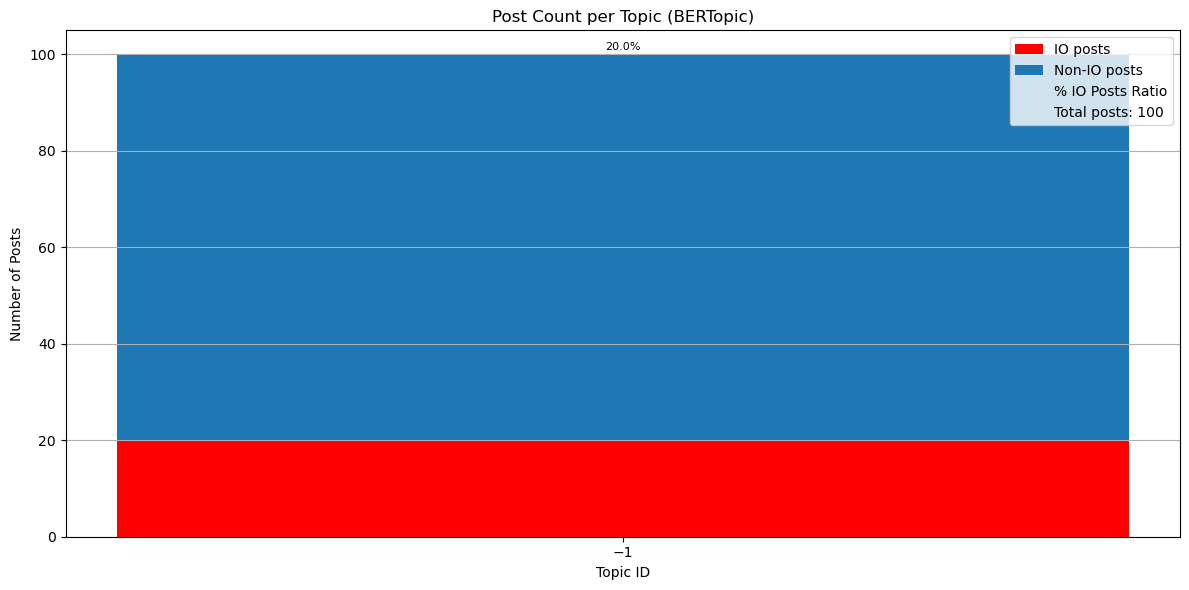

In [163]:
topic_col_name = "BERTopic_topic"
BERT_topic_stats = make_topic_stats(df, topic_col_name)
plot_topic_stats(BERT_topic_stats, topic_col_name, "BERTopic", output_folder_path)

In [146]:
from IPython.display import display

try:
    fig = BERTopic_model.visualize_topics(custom_labels=True)
    display(fig)   # show it
except Exception as e:
    print("Not enough topics for visualization")
    print("Error:", e)

Not enough topics for visualization
Error: arrays used as indices must be of integer (or boolean) type


## K-Means

In [147]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def auto_kmeans_topics(embeddings, k_min=4, k_max=40, step = 2):
    best_k = None
    best_score = -1
    best_labels = None

    for k in range(k_min, k_max + 1, step):
        print(f"Trying k={k}")
        km = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = km.fit_predict(embeddings)
        score = silhouette_score(embeddings, labels)

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    return best_labels, best_k

In [148]:
# Add to df
labels, best_k = auto_kmeans_topics(embeddings)
df["K_Means_topic"] = labels
print(f"Best k: {best_k}")
df.head()

Trying k=4
Trying k=6
Trying k=8
Trying k=10
Trying k=12
Trying k=14
Trying k=16
Trying k=18
Trying k=20
Trying k=22
Trying k=24
Trying k=26
Trying k=28
Trying k=30
Trying k=32
Trying k=34
Trying k=36
Trying k=38
Trying k=40
Best k: 40


,postid,post_text,application_name,post_language,in_reply_to_postid,in_reply_to_accountid,post_time,accountid,account_profile_description,follower_count,...,reposted_postid,hashtags,urls,account_mentions,is_control,clean_post_text,clean_text_no_enteties,translated_post,BERTopic_topic,K_Means_topic
533553,63d8b55902c839bcca75c603fc27a8adddb3d295dd,HOY 20h00 | Conoce la información gubernamental más relevante de la semana en #ElGobiernoInforma https://9224fc69e9e83107e521499d75c88923cdbfa3c5f1,042bc4a3f4973060f4b166ba92732fc75b9f58ffc8,spa_Latn,None,None,2017-11-13 22:12:00,cf9df49a2ed509861be9393631f3b5899196dc8138,"Adoro los gatitos, muy solidaria. Comunicadora de origen. Odio las injusticias. Viva la Revolución del diálogo con 9c449c650540282e854384730623d9b0bf94f32390. Mi casita en Quito",139,...,f48c38a50e376b68b823246d3120f31bb4bebb3010,[ElGobiernoInforma],[https://9224fc69e9e83107e521499d75c88923cdbfa3c5f1],[bef0e7981715abed0539a1eb8eedfdbf59651779f2],False,hoy 20h00 | conoce la información gubernamental más relevante de la semana en hashtag_elgobiernoinforma url_9224fc69e9e83107e521499d75c88923cdbfa3c5f1,hoy 20h00 | conoce la información gubernamental más relevante de la semana en elgobiernoinforma <URL>,Today at 8:00 p.m. you get the most relevant government information of the week in the government information.,-1,35
509427,591a31d958edbc5f00fe89cb54d6b51d67faff9f3b,"“Para un manejo austero y transparente debemos empezar por casa”, @aae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d Moreno #ProgramaEconómicoEc",042bc4a3f4973060f4b166ba92732fc75b9f58ffc8,spa_Latn,None,None,2017-10-12 14:25:00,db93654a6af387f4ffcbd76a79f5ef6cd4831d2fe6,Periodista profesional. Soltera y con grandes aspiraciones en la vida. Luchadora de las causas justas. Me gusta Viajar y hacer amigos😎✈️💻📸.,120,...,e73d1357f846e0ea24aac24736484745ecbd0d36dd,[ProgramaEconómicoEc],[],"[d77588c443644c33536cb68bb7610be2626b47b9b9, aae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d]",False,"“para un manejo austero transparente debemos empezar por casa”, mention_aae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d moreno hashtag_programaeconómicoec","“para un manejo austero y transparente debemos empezar por casa”, <USER> moreno programaeconómicoec","for austerity and transparency management we must start at home,",-1,22
500199,5a7651f9d89fac7dc41d941112d7b8322387956733,"México, no olvides que no viste a ningún senador, a ningún diputado, a ningún político ayudando en esta desgracia, no lo olvides al votar.",072f1b013621f1b0d9753c98d97f5a0a97a8b68303,spa_Latn,None,None,2017-09-23 07:01:55,d2a12216283353bb6259e840da5c63792e4f9e537c,Tierra trágame y escúpeme a lado de cnco,409,...,a27cf8676e6f896d1f045038adace2f9e3209c7aee,[],[],[d9a15d71a43266e61de66e0a2c5a56d691aecfcb4e],True,"méxico, olvides que viste ningún senador, ningún diputado, ningún político ayudando en esta desgracia, lo olvides al votar.","méxico, no olvides que no viste a ningún senador, a ningún diputado, a ningún político ayudando en esta desgracia, no lo olvides al votar.","Mexico, don't forget that you didn't see any senator, any deputy, any politician helping with this misfortune, don't forget that when you vote.",-1,5
512447,e6d1432221404527eb404e3b156be71e905f20c548,#Ahora || Vcpdte del PSUV @128644b13bc71423811db6516187be88bb836c3def: Llamamos a los opositores nacionalistas a no dejarse arrastrar por quienes qu… https://bc49a2a8fda96854866d557469a078ab2dec893322,a20fd3edddb315e8a4abfdc03c03ce2a6bf795e456,spa_Latn,None,None,2017-10-16 18:37:31,9b7e60785e9a3c61a90fb08d1a6b867a80674e3c70,"Soldado, Periodista, Locutor, Historiador y Director de la Radio Comunitaria bba959e9c9191a00a12192bc7a0111660b111e2e33 Leal a mi Patria de rajucho y con las Botas puestas.",2170,...,None,[Ahora],[https://bc49a2a8fda96854866d557469a078ab2dec893322],[128644b13bc71423811db6516187be88bb836c3def],True,hashtag_ahora || vcpdte del psuv mention_128644b13bc71423811db6516187be88bb836c3def : llamamos los opositores nacionalistas dejarse arrastra

plot is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_11/2025_12_11/K-Means_topic_clustering.png


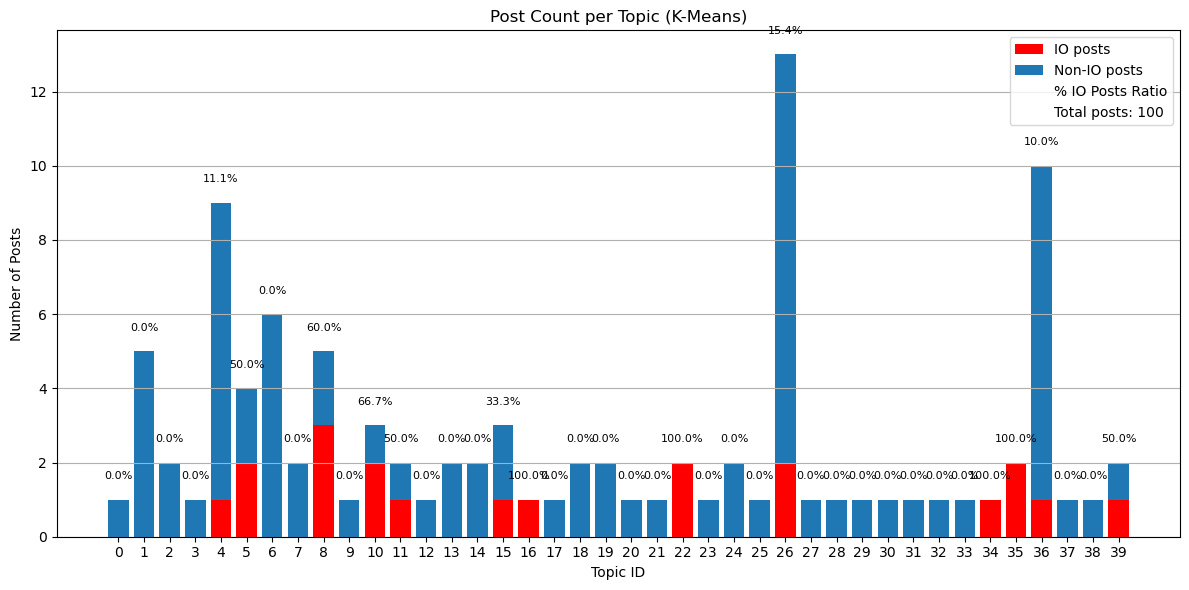

In [162]:
topic_col_name = "K_Means_topic"
topic_stats = make_topic_stats(df, topic_col_name)
plot_topic_stats(topic_stats, topic_col_name, "K-Means", output_folder_path)

# Named Entity Recognition (NER)

In [150]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

# Load model ONCE
tokenizer = AutoTokenizer.from_pretrained("TweebankNLP/bertweet-tb2_wnut17-ner")
ner_model = AutoModelForTokenClassification.from_pretrained("TweebankNLP/bertweet-tb2_wnut17-ner")

ner_pipeline = pipeline(
    "token-classification",
    model=ner_model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)


def extract_ner_entities(posts_lst: list):
    """
    Runs NER in batches on a list of text posts.

    Args:
          posts_lst (list): List of strings (cleaned posts).
    Returns
    -------
    all_entities (list[list[str]]): For each post: a list of extracted entity words.
    """

    ner_outputs = ner_pipeline(posts_lst)
    all_entities = []
    for post_output in ner_outputs:
        words = [ent["word"] for ent in post_output]
        all_entities.append(words)

    return all_entities

Device set to use cuda:0


In [151]:
# Apply ONCE, no pandas apply, in order to utilize batches.
df["ner_entities"] = extract_ner_entities(df["clean_post_text"].to_list())

In [152]:
df.loc[df["ner_entities"].astype(bool), ["clean_post_text", "ner_entities"]].head()

,clean_post_text,ner_entities
539489,"“les invito reflexionar que se trata de una época de paz, de comunión, de reunión, de conciliación amor”, mention_aae2514dd2b49b2e9005f27a9b7c88b4368e7b0c2d moreno hashtag_elgobiernoinforma",[elgobi@@]
504144,hace 43 años nos arrebataron la posibilidad de luchar juntos. la historia te reconoce como un héroe. te amo admiro hashtag_miguelenríquez url_e3a58f1d67d5a56faf4ccd1cd18608ea3b7afd91bb,[miguelenríquez]
536958,"roberto quiroz gana en tres sets 0-6, 6-4, 6-2, al chileno bastian malla se instala en semifinales mention_e4e96669d60e18e36102b60521ab2ef616ec5d9077 hashtag_santamarta url_f9cfadb38499da495cf9183b9737d83a9079951635","[roberto quiroz, santamar@@]"
506188,"torre del reloj torre morisca | construida el 1 agosto 1930 e inaugurada en 1931, de hormigón armado de 4 pisos. hashtag_vi …",[mor@@]
515177,lo dije en ese momento lo pienso ahora: la reelección indefinida es una distorsión de la vida democrática 3/7,[vida democrá@@]


# Entities Cleanup

In [164]:
def clean_entity_columns(df, entity_cols_lst):
    """Normalize entity columns to match TfidfVectorizer behavior.

    Converts each entity to a stripped, lowercase string for all columns
    listed in ``entity_cols_lst``. 
    The function modifies ``df``.

    Args:
        df: Input DataFrame.
        entity_cols_lst: Columns containing lists of entities.

    Returns:
        None.
    """
    for col in entity_cols_lst:
        df[col] = df[col].apply(lambda lst: [str(e).strip().lower().replace(" ", "_") for e in lst])

In [165]:
entity_cols_lst = ["hashtags", "account_mentions", "urls", "ner_entities"]
clean_entity_columns(df, entity_cols_lst)

# Entities Statistics

In [166]:
import pandas as pd

def compute_entity_topic_matrix(df, entity_col, topic_col="topic_id", is_control_col="is_control", output_folder_path=None):
    """
    Create a df where values = number of times the entity appears in each topic.

    Args:
        df (pd.DataFrame):
            DataFrame containing posts, entity lists, topic labels and is_control.
        entity_col (str):
            Column containing a list of entities per post.
        topic_col (str):
            Column containing topic labels.
        is_control_col (str):
            Boolean column: True = legitimate, False = IO.

    Returns:
        entity_topic_counts (pd.DataFrame):
            Columns:
                [entity, total_count, io_percent, topic_ids = 1, 2, 3...]
    """

    # 1) Explode entity lists → one row per (entity, topic, is_control)
    df_exp = (
        df[[entity_col, topic_col, is_control_col]]
        .explode(entity_col)
        .dropna(subset=[entity_col])
        .copy()
    )

    # 2) Aggregate counts per entity (overall)
    entity_stats = (
        df_exp.groupby(entity_col)
              .agg(
                  total_count=(entity_col, "count"),
                  io_count=(is_control_col, lambda x: (~x).sum()),  # False = IO
              )
              .reset_index()
    )
    entity_stats["io_percent"] = 100 * entity_stats["io_count"] / entity_stats["total_count"]
    entity_stats = entity_stats[[entity_col, "total_count", "io_percent"]]

    # 3) Count occurrences per (entity, topic)
    entity_topic_counts = (
        df_exp.groupby([entity_col, topic_col])
              .size()
              .reset_index(name="count")
    )

    # 4) Pivot to wide format (entity rows × topic columns)
    entity_topic_counts = (
        entity_topic_counts
        .pivot_table(
            index=entity_col,
            columns=topic_col,
            values="count",
            fill_value=0
        )
        .sort_index(axis=1)   # ensure topic columns sorted: 0,1,2,...
        .reset_index()
    )

    # 5) Merge total_count + IO stats
    entity_topic_counts = entity_stats.merge(entity_topic_counts, on=entity_col, how="left")

    # 6) Sort by total_count (descending)
    entity_topic_counts = entity_topic_counts.sort_values("total_count", ascending=False)

    # 7) Save if path provided
    if output_folder_path:
        output_path = Path(output_folder_path) / f"entity_topic_matrix.gzip.parquet"
        df.to_parquet(output_path, index=False, compression="gzip")
        print(f"Saved to {output_path}")

    return entity_topic_counts

In [167]:
import matplotlib.pyplot as plt

def plot_entity_topic_distribution(entity, entity_topic_counts, entity_col, clustering_model="", output_folder_path=None):
    """
    Plot how many times a given entity appears in each topic.
    """

    # Extract row for chosen entity
    row = entity_topic_counts.loc[entity_topic_counts[entity_col] == entity].iloc[0]

    # Keep only topic columns (s)
    topic_cols = [c for c in entity_topic_counts.columns if isinstance(c, int)]
    counts = row[topic_cols]       # Series like [topic_id → count]

    # --- Plot ---
    plt.figure(figsize=(12, 5))
    plt.bar(topic_cols, counts)

    plt.title(f"Topic Distribution for Entity: '{entity}'")
    plt.xlabel("Topic ID")
    plt.ylabel("Count of occurrences")
    plt.xticks(topic_cols)
    plt.grid(axis="y")
    plt.ylim(0, counts.max()* 1.15 ) # y-axis height: 15% padding above the tallest bar
    # Add metadata note (top-right)
    plt.text(
        0.98, 0.92,
        f"clustering model: {clustering_model}\nEntities col: {entity_col}",
        ha="right",
        va="top",
        transform=plt.gca().transAxes
    )

    # plot
    plt.tight_layout()

    # Save if path provided
    if output_folder_path:
        plot_path = output_folder_path / f"{entity}_topic_distribution.png"
        plt.savefig(plot_path, dpi=300)
        print(f"Saved figure to: {plot_path}")

    plt.show()

    plt.close()

,ner_entities,total_count,io_percent,-1
22,ecuador,7,42.857143,7.0
12,chile,3,0.000000,3.0
60,twitter,2,0.000000,2.0
5,apple,2,0.000000,2.0
21,ecu@@,2,0.000000,2.0


Saved figure to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_11/2025_12_11/ecuador_topic_distribution.png


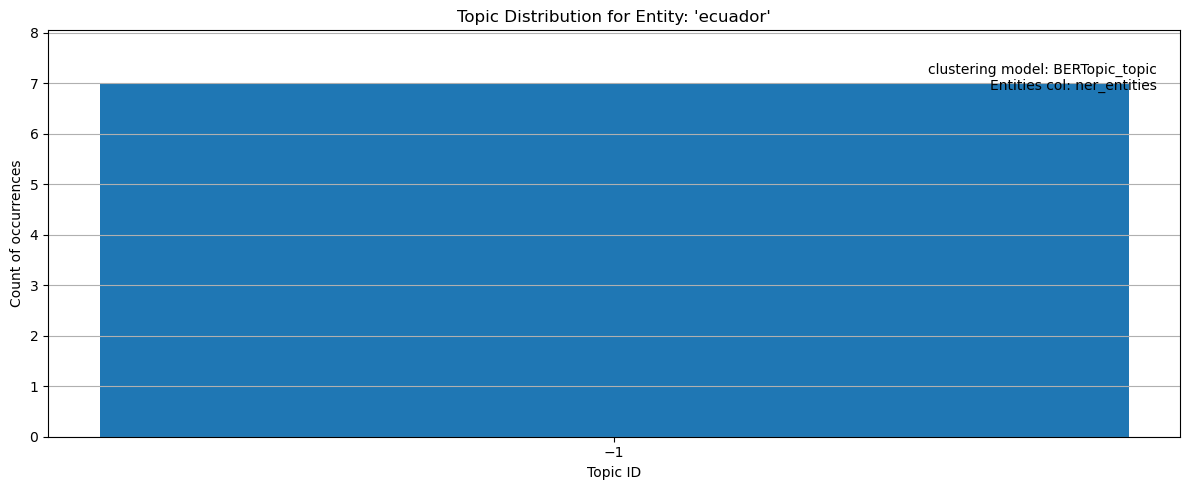

In [168]:
entity_col_name = "ner_entities"
topic_col = "BERTopic_topic"

entity_topic_matrix = compute_entity_topic_matrix(df, entity_col_name, topic_col)
display(entity_topic_matrix.head())

entity = entity_topic_matrix[entity_col_name].iloc[0]   # first entity
plot_entity_topic_distribution(entity=entity, entity_topic_counts=entity_topic_matrix, entity_col=entity_col_name, clustering_model = topic_col, output_folder_path=output_folder_path)

# Save to parquet

In [169]:
# print dataset statistics
for col in df.columns:
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")

postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | list
urls                           | list
account_mentions               | list
is_control                     | bool
clean_post_text                | str
clean_text_no_enteties         | str
translated_post                | str
BERTopic_topic                 | int64
K_Means_topic                  | int32
ner_entities                   | list


In [170]:
df_output_path = output_folder_path / f"Topic_Ner_{file_name}"

df.to_parquet(df_output_path, index=False, compression="gzip")
print("df is saved to:", df_output_path)

df is saved to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_11/2025_12_11/Topic_Ner_Ecuador_part_11.gzip.parquet
